In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

In [2]:
import numpy as np
import pandas as pd
df=pd.read_csv("./GIT/nilo_it_index.csv", sep=",",index_col=0)
df.index = pd.to_datetime(df.index)
df

,NumValue,TG,HU,RR,FG
2008-01-01,0.0,78.179724,79.204301,21.654378,23.483871
2008-02-01,0.0,82.448276,73.965517,8.975369,21.126437
2008-03-01,0.0,114.023041,70.887097,15.396313,25.537634
2008-04-01,0.0,143.000000,67.327778,21.019048,28.300000
2008-05-01,0.0,191.788018,66.747312,28.382488,21.924731
...,...,...,...,...,...
2023-08-01,183.0,257.458065,62.354839,22.881720,16.820381
2023-09-01,75.0,232.473333,66.433333,8.011111,15.841667
2023-10-01,18.0,193.954194,76.403226,25.946237,19.439150
2023-11-01,4.0,121.602529,79.533333,17.500000,20.966667


In [3]:
df.corr(method='pearson')

,NumValue,TG,HU,RR,FG
NumValue,1.000000,0.357172,-0.206925,-0.014716,-0.078931
TG,0.357172,1.000000,-0.670767,-0.067865,-0.294595
HU,-0.206925,-0.670767,1.000000,0.286601,0.065789
RR,-0.014716,-0.067865,0.286601,1.000000,0.265370
FG,-0.078931,-0.294595,0.065789,0.265370,1.000000


### Cálculo de la ventana deslizante

In [4]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]
    for start in range(n-window):
        end = start + window
        x.append(d[start:end])
    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)
    return pd.concat([df_y,df_xs], axis=1).dropna()

In [5]:
df_inf=one_step_forecast(df.iloc[:,0],4) #ventana deslizante de infectados
df_temp=one_step_forecast(df.iloc[:,1],4).iloc[:,1:].rename({'x_1':'x_1_temp','x_2':'x_2_temp','x_3':'x_3_temp','x_4':'x_4_temp'},axis=1) #ventana deslizante de temperatura

In [6]:
df=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_inf.iloc[:,2],df_temp.iloc[:,1],df_inf.iloc[:,3],df_temp.iloc[:,2],df_inf.iloc[:,4],df_temp.iloc[:,3]],axis=1)
df

,y,x_1,x_1_temp,x_2,x_2_temp,x_3,x_3_temp,x_4,x_4_temp
2008-01-01,0.0,0.0,78.179724,0.0,82.448276,0.0,114.023041,0.0,143.000000
2008-02-01,0.0,0.0,82.448276,0.0,114.023041,0.0,143.000000,0.0,191.788018
2008-03-01,0.0,0.0,114.023041,0.0,143.000000,0.0,191.788018,0.0,231.476190
2008-04-01,0.0,0.0,143.000000,0.0,191.788018,0.0,231.476190,0.0,256.493088
2008-05-01,1.0,0.0,191.788018,0.0,231.476190,0.0,256.493088,0.0,260.852535
...,...,...,...,...,...,...,...,...,...
2023-04-01,183.0,0.0,134.103563,1.0,181.330968,0.0,194.293333,63.0,267.715484
2023-05-01,75.0,1.0,181.330968,0.0,194.293333,63.0,267.715484,183.0,257.458065
2023-06-01,18.0,0.0,194.293333,63.0,267.715484,183.0,257.458065,75.0,232.473333
2023-07-01,4.0,63.0,267.715484,183.0,257.458065,75.0,232.473333,18.0,193.954194


### Normalización y separación en test y train 

In [7]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

In [8]:
train,test=split_data(df)

In [9]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm=pd.DataFrame(norm.fit_transform(train),index=train.index,columns=train.columns)
test_norm=pd.DataFrame(norm.transform(test),index=test.index,columns=test.columns)

In [10]:
xtrainN=train_norm.iloc[:,1:]
xtestN=test_norm.iloc[:,1:]
ytrainN=train_norm.iloc[:,0]
ytestN=test_norm.iloc[:,0]

### Regresión lineal

In [11]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(xtrainN,ytrainN)
ypred=regr.predict(xtestN)
Y_rl=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_rl['ypred']=pd.DataFrame(ypred,index=ytestN.index)
Y_rl

,ytest,ypred
2022-03-01,0.639296,0.049248
2022-04-01,1.146628,0.550957
2022-05-01,0.284457,0.621536
2022-06-01,0.043988,-0.207216
2022-07-01,0.005865,0.140602
2022-08-01,0.000000,-0.046512
2022-09-01,0.000000,-0.018507
2022-10-01,0.000000,-0.005198
2022-11-01,0.000000,-0.005015
2022-12-01,0.000000,0.012802


In [12]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(ytestN, ypred)
r2=r2_score(ytestN, ypred)
print(mse)
print(r2)

0.059609733660889314
0.34408476066964067


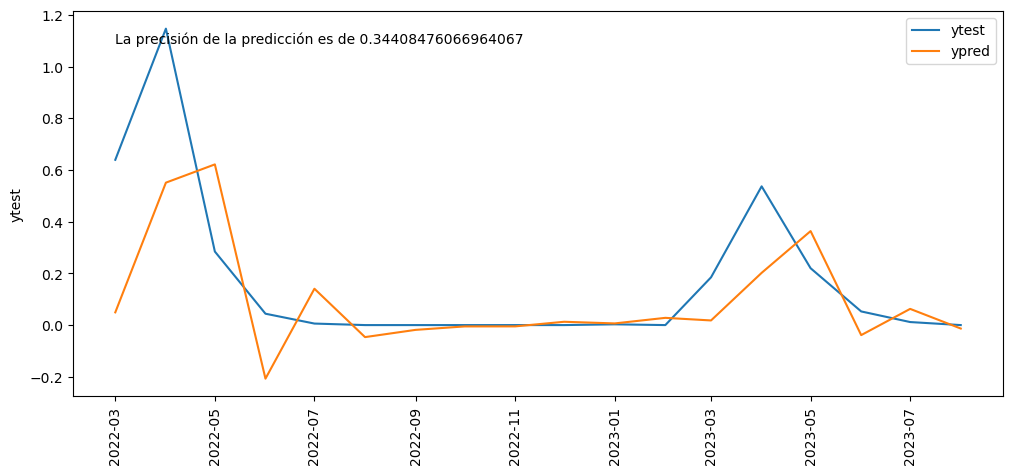

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ytest,label='ytest')
sns.lineplot(data=Y_rl,x=Y_rl.index,y=Y_rl.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_rl.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rl.ytest, Y_rl.ypred)), fontsize=10)
plt.show()

### KNNeighbors

In [14]:
from sklearn.neighbors import KNeighborsRegressor
v=[]
for k in range(1,15):
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(xtrainN,ytrainN)
    ypred=knn.predict(xtestN.values.astype(np.float32))
    v.append(r2_score(ytestN, ypred))

v

[0.3012003503589602,
 0.30195212091881896,
 0.3203141314465273,
 0.24205789012992995,
 0.18444691270261482,
 0.13233323120858353,
 0.1419865681585727,
 0.11208126175371647,
 0.08176908364179258,
 0.06166422258483484,
 0.05136483079331988,
 0.037901729218319025,
 0.03615759999491064,
 0.027458207207995744]

In [15]:
knn=KNeighborsRegressor(n_neighbors=3)
knn.fit(xtrainN,ytrainN)

KNeighborsRegressor(n_neighbors=3)

In [16]:
ypred_knn=knn.predict(xtestN.values.astype(np.float32))
Y_knn=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_knn['ypred']=pd.DataFrame(ypred_knn,index=ytestN.index)
Y_knn

,ytest,ypred
2022-03-01,0.639296,0.010753
2022-04-01,1.146628,0.436950
2022-05-01,0.284457,0.444770
2022-06-01,0.043988,0.011730
2022-07-01,0.005865,0.000978
2022-08-01,0.000000,0.000978
2022-09-01,0.000000,0.000000
2022-10-01,0.000000,0.000000
2022-11-01,0.000000,0.000000
2022-12-01,0.000000,0.000000


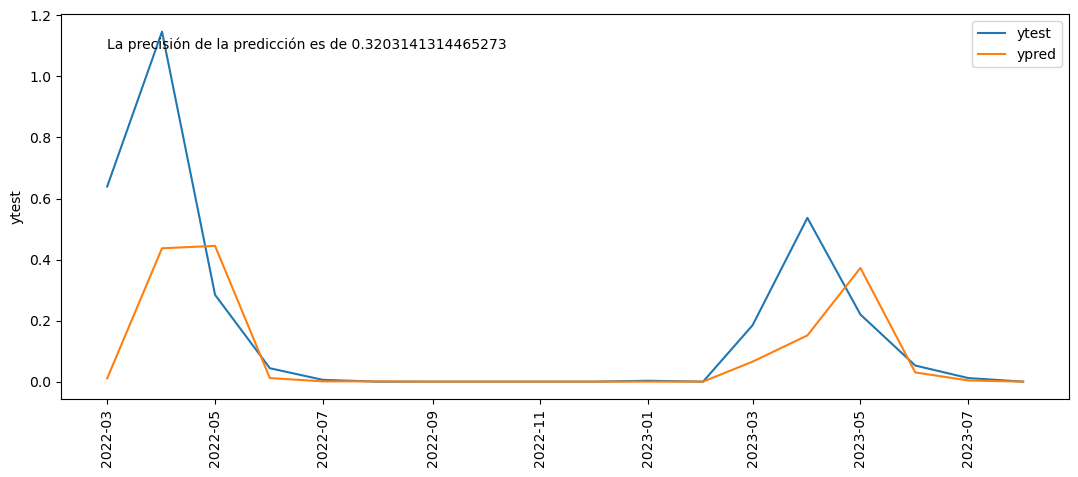

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ytest,label='ytest')
sns.lineplot(data=Y_knn,x=Y_knn.index,y=Y_knn.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_knn.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_knn.ytest, Y_knn.ypred)), fontsize=10)
plt.show()

### Random Forest 

In [18]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [19]:
rf=RandomForestRegressor(random_state=0)
rf.fit(xtrainN,ytrainN)

RandomForestRegressor(random_state=0)

In [20]:
ypred=rf.predict(xtestN.values.astype(np.float32))
Y_rf=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_rf['ypred']=pd.DataFrame(ypred,index=ytestN.index)
Y_rf

,ytest,ypred
2022-03-01,0.639296,0.248710
2022-04-01,1.146628,0.695953
2022-05-01,0.284457,0.485191
2022-06-01,0.043988,0.052434
2022-07-01,0.005865,0.001496
2022-08-01,0.000000,0.001789
2022-09-01,0.000000,0.000000
2022-10-01,0.000000,0.000000
2022-11-01,0.000000,0.000000
2022-12-01,0.000000,0.000088


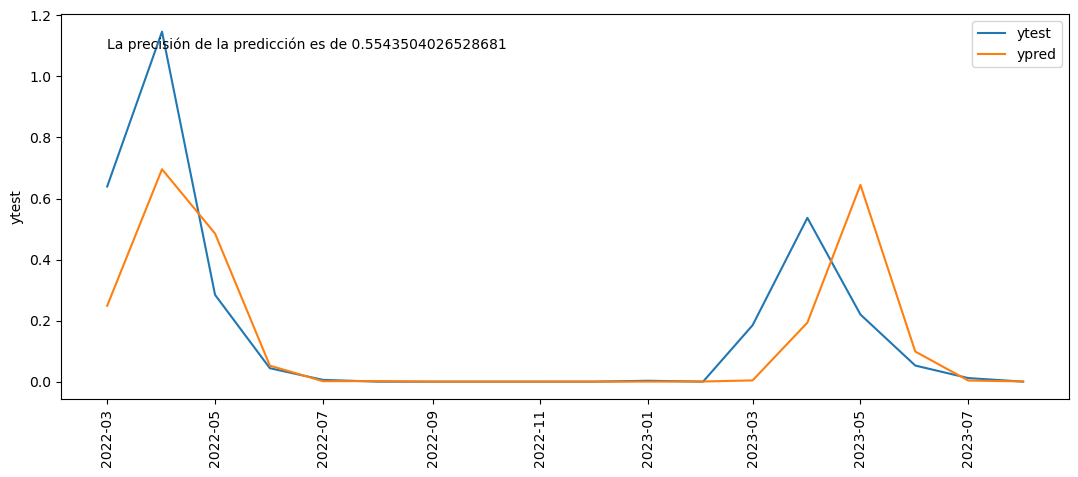

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ytest,label='ytest')
sns.lineplot(data=Y_rf,x=Y_rf.index,y=Y_rf.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_rf.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rf.ytest, Y_rf.ypred)), fontsize=10)
plt.show()

### Gradient Boosting

In [22]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(random_state=0)
gbr.fit(xtrainN,ytrainN)
ypred_gbr=gbr.predict(xtestN.values.astype(np.float32))
Y_gbr=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
Y_gbr['ypred']=pd.DataFrame(ypred_gbr,index=ytestN.index)
Y_gbr

,ytest,ypred
2022-03-01,0.639296,0.326764
2022-04-01,1.146628,0.802266
2022-05-01,0.284457,0.337809
2022-06-01,0.043988,0.030030
2022-07-01,0.005865,0.002311
2022-08-01,0.000000,0.010484
2022-09-01,0.000000,0.000306
2022-10-01,0.000000,-0.001350
2022-11-01,0.000000,-0.000674
2022-12-01,0.000000,0.001955


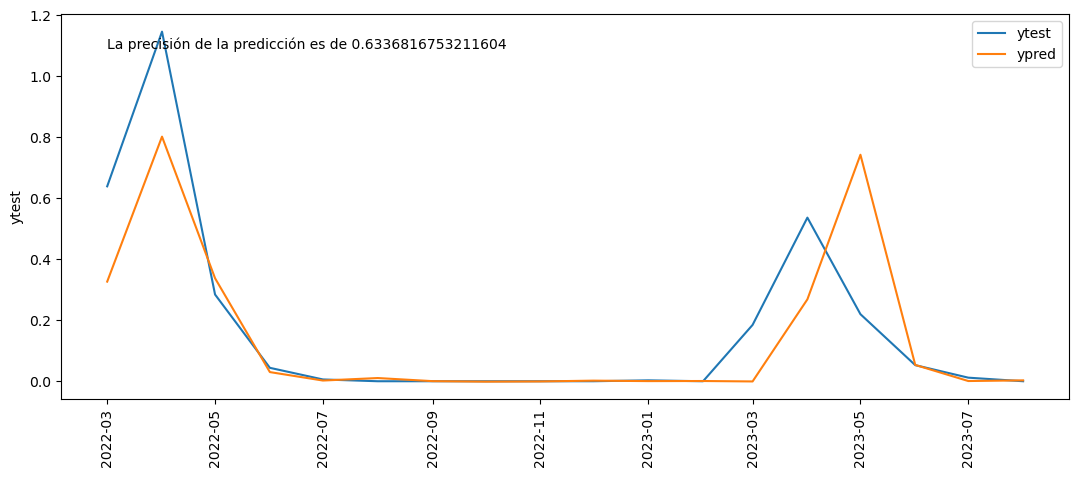

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ytest,label='ytest')
sns.lineplot(data=Y_gbr,x=Y_gbr.index,y=Y_gbr.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 3, 1), 0.95*max(Y_gbr.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_gbr.ytest, Y_gbr.ypred)), fontsize=10)
plt.show()

### Validación

In [24]:
xtrainN,xvalN=split_data(xtrainN)
ytrainN,yvalN=split_data(ytrainN)

### RNA

In [25]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense
from tensorflow.keras.optimizers import Adam

In [26]:
Y_rna=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rna=Sequential()
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu',input_dim=(len(xtrainN.columns))))
    rna.add(Dropout(0.1))
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna.add(Dropout(0.1))
    rna.add(Dense(units=32,kernel_initializer='uniform',activation='relu'))
    rna.add(Dropout(0.1))
    rna.add(Dense(1))
    rna.compile(optimizer='Adam',loss='mean_squared_error')
    rna.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rna=rna.predict(xtestN)
    Y_rna['ypred_'+str(i)]=pd.DataFrame(ypred_rna,index=ytestN.index)
    
Y_rna

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0055 - val_loss: 8.2164e-04
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 9.4254e-04
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - val_loss: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - val_loss: 9.8674e-04
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0055 - val_loss: 9.1736e-04
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054 - val_loss: 8.4458e-04
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0054 - val_loss: 7.7949e-04
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 7.2097e-04
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052 - val_loss: 6.7166e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - val_loss: 6.0455e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0050 - val_loss: 5.5142e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0

Epoch 68/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - val_loss: 1.4690e-04
Epoch 69/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 1.3534e-04
Epoch 70/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - val_loss: 2.1171e-04
Epoch 71/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019 - val_loss: 2.7776e-04
Epoch 72/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - val_loss: 1.5257e-04
Epoch 73/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0021 - val_loss: 6.0005e-04
Epoch 74/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - val_loss: 1.2557e-04
Epoch 75/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 2.9699e-04
Epoch 76/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 1.9009e-04
Epoch 77/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 3.3847e-04
Epoch 78/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - val_loss: 2.1432e-04
Epoch 79/500
5/5 ━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0013 - val_loss: 1.3354e-04
Epoch 201/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - val_loss: 1.6147e-04
Epoch 202/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - val_loss: 5.9451e-04
Epoch 203/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0016 - val_loss: 1.6260e-04
Epoch 204/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 1.2387e-04
Epoch 205/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 1.4861e-04
Epoch 206/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 1.7386e-04
Epoch 207/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.2190e-04
Epoch 208/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 3.2377e-04
Epoch 209/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 2.3046e-04
Epoch 210/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0013 - val_loss: 1.3581e-04
Epoch 211/500
5/5 ━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 8.0649e-05
Epoch 267/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.9021e-04 - val_loss: 6.8905e-05
Epoch 268/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.6225e-04 - val_loss: 4.7908e-04
Epoch 269/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014 - val_loss: 5.9085e-04
Epoch 270/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019 - val_loss: 8.3565e-05
Epoch 271/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.8971e-04 - val_loss: 1.8991e-04
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 1.0045e-04
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 8.4963e-05
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 7.3499e-05
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 1.3593e-04
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 2.2997e-04
Epoch 277/500
5/5 ━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - val_loss: 8.3261e-05
Epoch 397/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.2370e-04 - val_loss: 7.2248e-05
Epoch 398/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.5696e-04 - val_loss: 0.0011
Epoch 399/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020 - val_loss: 6.3351e-05
Epoch 400/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.7354e-04 - val_loss: 5.7250e-05
Epoch 401/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.6672e-04 - val_loss: 8.3259e-05
Epoch 402/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 3.5788e-04
Epoch 403/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.7531e-04 - val_loss: 7.2451e-05
Epoch 404/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.6295e-04 - val_loss: 1.0546e-04
Epoch 405/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3410e-04 - val_loss: 1.0636e-04
Epoch 406/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.9548e-04 - val_loss: 4.6572e-05
Epoch 4

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 1.8489e-04
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 2.0399e-04
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - val_loss: 2.6648e-04
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 - val_loss: 3.8189e-04
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - val_loss: 1.9754e-04
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 1.8523e-04
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 1.7166e-04
Epoch 148/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - val_loss: 2.3883e-04
Epoch 149/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013 - val_loss: 1.8613e-04
Epoch 150/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 1.6350e-04
Epoch 151/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 1.9054e-04
Epoch 152/500
5/5 ━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 1.3708e-04
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 1.2597e-04
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.8153e-04 - val_loss: 3.7148e-04
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 2.0011e-04
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 1.1175e-04
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 1.3723e-04
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - val_loss: 4.7496e-04
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 2.0166e-04
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 1.3828e-04
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 5.4849e-04
Epoch 283/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 4.1218e-04
Epoch 284/500
5/5 ━━━━

Epoch 339/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.7236e-04 - val_loss: 4.6684e-04
Epoch 340/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.6292e-04 - val_loss: 3.9280e-04
Epoch 341/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.9318e-04 - val_loss: 3.1151e-04
Epoch 342/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.8834e-04 - val_loss: 3.9148e-04
Epoch 343/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.7077e-04
Epoch 344/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.0863e-04 - val_loss: 1.5916e-04
Epoch 345/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.0705e-04 - val_loss: 3.6979e-04
Epoch 346/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.8333e-04 - val_loss: 8.2077e-04
Epoch 347/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 2.5437e-04
Epoch 348/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 1.8021e-04
Epoch 349/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.9120e-04 - val

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 4.8336e-05
Epoch 470/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.5031e-04 - val_loss: 6.5584e-05
Epoch 471/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.0679e-04 - val_loss: 0.0013
Epoch 472/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0010 - val_loss: 3.6805e-04
Epoch 473/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.1740e-04 - val_loss: 1.2904e-04
Epoch 474/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3015e-04 - val_loss: 7.2631e-04
Epoch 475/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.5868e-04 - val_loss: 0.0022
Epoch 476/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - val_loss: 4.6145e-05
Epoch 477/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.9867e-04 - val_loss: 2.6213e-04
Epoch 478/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.0055e-04 - val_loss: 0.0029
Epoch 479/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - val_loss: 1.0290e-04
Epoch 480/500
5

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-03-01,0.639296,0.234787,0.287789,0.377292,0.344921
2022-04-01,1.146628,1.140962,1.509847,1.378621,1.307402
2022-05-01,0.284457,0.147354,0.246371,0.180228,0.241641
2022-06-01,0.043988,0.037350,0.020497,0.024961,0.005877
2022-07-01,0.005865,0.010319,0.002403,0.003449,0.002845
2022-08-01,0.000000,0.006381,0.003210,0.000991,0.002175
2022-09-01,0.000000,0.006383,0.000875,0.001033,0.002366
2022-10-01,0.000000,0.007754,0.000852,0.001450,0.002747
2022-11-01,0.000000,0.007209,0.000709,0.000993,0.002746
2022-12-01,0.000000,0.006650,0.001798,0.000477,0.002675


In [27]:
v=[]
for i in range(4):
    v.append(r2_score(Y_rna.iloc[:,0], Y_rna.iloc[:,i+1]))

v

[0.8651848043648174,
 0.8210405231233664,
 0.8875484950738882,
 0.9068466802321159]

### RNN

In [28]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import SimpleRNN, Dropout, Dense

In [29]:
Y_rnn=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rnn1=Sequential()
    rnn1.add(SimpleRNN(32, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    rnn1.add(Dropout(0.1))
    rnn1.add(Dense(1))
    rnn1.compile(optimizer='Adam',loss='mean_squared_error')
    rnn1.fit(xtrainN,ytrainN,batch_size=32,epochs=500,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_rnn=rnn1.predict(xtestN)
    Y_rnn['ypred_'+str(i)]=pd.DataFrame(ypred_rnn,index=ytestN.index)
    
Y_rnn

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0163 - val_loss: 0.0016
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0099 - val_loss: 8.4279e-04
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0112 - val_loss: 5.6868e-04
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0102 - val_loss: 4.5002e-04
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0085 - val_loss: 5.2096e-04
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0068 - val_loss: 4.5118e-04
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0090 - val_loss: 3.4897e-04
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0084 - val_loss: 2.9210e-04
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0069 - val_loss: 2.7923e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0068 - val_loss: 3.4353e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0066 - val_loss: 4.3434e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 1.4859e-04
Epoch 134/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 2.0788e-04
Epoch 135/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012 - val_loss: 2.1492e-04
Epoch 136/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - val_loss: 1.3387e-04
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013 - val_loss: 1.5970e-04
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 3.0342e-04
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 1.7814e-04
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 1.6095e-04
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 1.4524e-04
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.1348e-04 - val_loss: 2.1511e-04
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011 - val_loss: 1.5331e-04
Epoch 144/500
5/5 ━━━━━━━━━

Epoch 198/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.9875e-04 - val_loss: 1.3140e-04
Epoch 199/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.0207e-04 - val_loss: 9.8181e-05
Epoch 200/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.1713e-04 - val_loss: 9.3922e-05
Epoch 201/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.1859e-04 - val_loss: 1.2980e-04
Epoch 202/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.3637e-04 - val_loss: 1.3693e-04
Epoch 203/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.1755e-04 - val_loss: 1.1912e-04
Epoch 204/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.3825e-04 - val_loss: 6.5367e-05
Epoch 205/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.7564e-04 - val_loss: 7.2300e-05
Epoch 206/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.3669e-04 - val_loss: 4.9561e-05
Epoch 207/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.2728e-04 - val_loss: 5.1509e-05
Epoch 208/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.113

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.7066e-04 - val_loss: 1.0874e-04
Epoch 327/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.5052e-04 - val_loss: 1.4720e-04
Epoch 328/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.6505e-04 - val_loss: 6.8483e-05
Epoch 329/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.7194e-04 - val_loss: 5.8304e-05
Epoch 330/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0694e-04 - val_loss: 3.4596e-05
Epoch 331/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0048e-04 - val_loss: 4.3626e-05
Epoch 332/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.9602e-04 - val_loss: 4.4097e-05
Epoch 333/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.4054e-04 - val_loss: 3.1838e-05
Epoch 334/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.9397e-04 - val_loss: 4.3635e-05
Epoch 335/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.4481e-04 - val_loss: 1.0786e-04
Epoch 336/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.4733e-04 - va

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3719e-04 - val_loss: 9.3976e-05
Epoch 455/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4937e-04 - val_loss: 4.6003e-05
Epoch 456/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9174e-04 - val_loss: 2.4115e-05
Epoch 457/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.7111e-04 - val_loss: 2.8853e-05
Epoch 458/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9286e-04 - val_loss: 2.7800e-05
Epoch 459/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0614e-04 - val_loss: 4.6320e-05
Epoch 460/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9921e-04 - val_loss: 2.4895e-04
Epoch 461/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.4521e-04 - val_loss: 1.6594e-04
Epoch 462/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3036e-04 - val_loss: 5.3003e-05
Epoch 463/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.9747e-04 - val_loss: 4.3180e-05
Epoch 464/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9248e-04 - val_

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 4.2089e-04
Epoch 109/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 3.6003e-04
Epoch 110/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9393e-04 - val_loss: 4.0830e-04
Epoch 111/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.5369e-04 - val_loss: 3.4147e-04
Epoch 112/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.6889e-04 - val_loss: 3.1870e-04
Epoch 113/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.8315e-04 - val_loss: 3.6871e-04
Epoch 114/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.0127e-04 - val_loss: 3.4777e-04
Epoch 115/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.1412e-04 - val_loss: 2.9162e-04
Epoch 116/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.7981e-04 - val_loss: 3.4132e-04
Epoch 117/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 4.0877e-04
Epoch 118/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.6091e-04 - val_loss: 3.3

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.5773e-04 - val_loss: 2.4028e-04
Epoch 237/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3529e-04 - val_loss: 1.9271e-04
Epoch 238/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.1111e-04 - val_loss: 1.9982e-04
Epoch 239/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.0868e-04 - val_loss: 1.0477e-04
Epoch 240/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.5522e-04 - val_loss: 6.7857e-05
Epoch 241/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.7148e-04 - val_loss: 8.7768e-05
Epoch 242/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.4243e-04 - val_loss: 2.0871e-04
Epoch 243/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.7722e-04 - val_loss: 1.6858e-04
Epoch 244/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.5572e-04 - val_loss: 1.7229e-04
Epoch 245/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.5432e-04 - val_loss: 1.8360e-04
Epoch 246/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.9822e-04 - val_loss: 1.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.8409e-04 - val_loss: 1.7458e-04
Epoch 365/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - val_loss: 2.1816e-04
Epoch 366/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.7765e-04 - val_loss: 1.3835e-04
Epoch 367/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.2697e-04 - val_loss: 5.5868e-05
Epoch 368/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.9658e-04 - val_loss: 7.4318e-05
Epoch 369/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.8655e-04 - val_loss: 1.7575e-04
Epoch 370/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3664e-04 - val_loss: 1.8523e-04
Epoch 371/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.9684e-04 - val_loss: 1.1737e-04
Epoch 372/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9411e-04 - val_loss: 1.0243e-04
Epoch 373/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5483e-04 - val_loss: 2.2299e-04
Epoch 374/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.3452e-04 - val_loss:

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4686e-04 - val_loss: 1.6243e-04
Epoch 493/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.9394e-04 - val_loss: 1.5199e-04
Epoch 494/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7554e-04 - val_loss: 1.3455e-04
Epoch 495/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.4583e-04 - val_loss: 1.4993e-04
Epoch 496/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4479e-04 - val_loss: 1.6884e-04
Epoch 497/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.6948e-04 - val_loss: 9.4444e-05
Epoch 498/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.1091e-04 - val_loss: 1.0964e-04
Epoch 499/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9598e-04 - val_loss: 1.6018e-04
Epoch 500/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.1043e-04 - val_loss: 1.4175e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-03-01,0.639296,0.084199,0.035107,0.059781,0.067284
2022-04-01,1.146628,1.379951,1.211238,1.246527,1.291367
2022-05-01,0.284457,0.293649,0.245088,0.204585,0.266443
2022-06-01,0.043988,0.029342,-0.008190,0.020189,0.023649
2022-07-01,0.005865,0.169269,-0.007167,0.078039,0.006951
2022-08-01,0.000000,0.013598,0.003809,0.004318,-0.001724
2022-09-01,0.000000,0.003497,0.001591,-0.001054,0.001063
2022-10-01,0.000000,0.002490,0.002753,0.002319,-0.000558
2022-11-01,0.000000,0.001764,0.001402,0.000692,-0.001620
2022-12-01,0.000000,0.005635,0.000506,-0.002297,-0.004303


In [30]:
w=[]
for i in range(4):
    w.append(r2_score(Y_rnn.iloc[:,0], Y_rnn.iloc[:,i+1]))

w

[0.7163584995276431,
 0.6973844847712836,
 0.7568808904747764,
 0.7414033052217797]

### LSTM

In [31]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dense, LSTM, Dropout

In [32]:
Y_lstm=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    lstm = Sequential()
    lstm.add(LSTM(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    lstm.add(Dropout(0.1))
    lstm.add(Dense(1))
    lstm.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error')
    lstm.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN))
    ypred_lstm=lstm.predict(xtestN) 
    Y_lstm['ypred_'+str(i)]=pd.DataFrame(ypred_lstm,index=ytestN.index)

Y_lstm

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0058 - val_loss: 0.0011
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0056 - val_loss: 5.8528e-04
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - val_loss: 7.6869e-04
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0050 - val_loss: 7.9799e-04
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0054 - val_loss: 5.8041e-04
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 5.7122e-04
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0051 - val_loss: 6.6487e-04
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0051 - val_loss: 7.1866e-04
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053 - val_loss: 5.9712e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0050 - val_loss: 5.8834e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - val_loss: 6.3504e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0019 - val_loss: 3.3746e-04
Epoch 134/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0020 - val_loss: 2.4763e-04
Epoch 135/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 5.5447e-04
Epoch 136/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 4.1842e-04
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 4.7507e-04
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 3.4145e-04
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 3.4212e-04
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0013 - val_loss: 3.1452e-04
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 3.3205e-04
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 3.5861e-04
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 3.1301e-04
Epoch 144/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 2.5348e-04
Epoch 266/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.0502e-04 - val_loss: 2.4365e-04
Epoch 267/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.4818e-04 - val_loss: 3.2367e-04
Epoch 268/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.6320e-04 - val_loss: 3.3866e-04
Epoch 269/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.5921e-04 - val_loss: 2.9474e-04
Epoch 270/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.7607e-04 - val_loss: 2.0297e-04
Epoch 271/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6125e-04 - val_loss: 2.7904e-04
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.7802e-04 - val_loss: 2.5239e-04
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.9143e-04 - val_loss: 1.9296e-04
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.4443e-04 - val_loss: 1.6469e-04
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7002e-04 - val_l

Epoch 330/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 2.8899e-04
Epoch 331/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 6.9516e-04
Epoch 332/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 6.2986e-04
Epoch 333/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 6.4986e-05
Epoch 334/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.9894e-04 - val_loss: 9.8270e-05
Epoch 335/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.9459e-04 - val_loss: 1.5006e-04
Epoch 336/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.1019e-04 - val_loss: 1.5651e-04
Epoch 337/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.2094e-04 - val_loss: 2.6487e-05
Epoch 338/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9564e-04 - val_loss: 6.7040e-05
Epoch 339/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3007e-04 - val_loss: 4.9732e-05
Epoch 340/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5226e-04 - val

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.1285e-04 - val_loss: 8.1506e-05
Epoch 459/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1956e-04 - val_loss: 8.8315e-05
Epoch 460/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.8817e-04 - val_loss: 1.5054e-04
Epoch 461/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.7843e-04 - val_loss: 1.4920e-04
Epoch 462/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7693e-04 - val_loss: 1.6371e-04
Epoch 463/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7458e-04 - val_loss: 1.6855e-04
Epoch 464/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.6141e-04 - val_loss: 1.2608e-04
Epoch 465/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.8402e-04 - val_loss: 9.1430e-05
Epoch 466/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.5518e-04 - val_loss: 6.0916e-05
Epoch 467/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9979e-04 - val_loss: 6.0617e-05
Epoch 468/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2789e-04 - v

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0010 - val_loss: 3.0186e-04
Epoch 271/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 3.0290e-04
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 3.0351e-04
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 2.9239e-04
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012 - val_loss: 2.9230e-04
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 3.3196e-04
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - val_loss: 3.4390e-04
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 3.8815e-04
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014 - val_loss: 3.3240e-04
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 3.1364e-04
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 3.6818e-04
Epoch 281/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 3.9490e-04
Epoch 337/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 2.8639e-04
Epoch 338/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 2.9095e-04
Epoch 339/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 2.8262e-04
Epoch 340/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 3.0219e-04
Epoch 341/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 3.1487e-04
Epoch 342/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012 - val_loss: 3.0143e-04
Epoch 343/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 2.4233e-04
Epoch 344/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 2.7765e-04
Epoch 345/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 2.4153e-04
Epoch 346/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015 - val_loss: 2.7823e-04
Epoch 347/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 2.4854e-04
Epoch 403/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0010 - val_loss: 2.1332e-04
Epoch 404/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 2.4145e-04
Epoch 405/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - val_loss: 2.6968e-04
Epoch 406/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 2.6077e-04
Epoch 407/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 2.1788e-04
Epoch 408/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 1.4547e-04
Epoch 409/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 1.2868e-04
Epoch 410/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017 - val_loss: 2.4647e-04
Epoch 411/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 4.3260e-04
Epoch 412/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 4.5471e-04
Epoch 413/500
5/5 ━━━━━━

Epoch 468/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 3.6118e-04
Epoch 469/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012 - val_loss: 3.5533e-04
Epoch 470/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6645e-04 - val_loss: 2.3254e-04
Epoch 471/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 1.9802e-04
Epoch 472/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 1.9159e-04
Epoch 473/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 2.0250e-04
Epoch 474/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.0224e-04 - val_loss: 1.7806e-04
Epoch 475/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 1.2891e-04
Epoch 476/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - val_loss: 1.4592e-04
Epoch 477/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.3303e-04 - val_loss: 1.8568e-04
Epoch 478/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 1.9306e-0

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-03-01,0.639296,0.430080,0.226352,0.121652,0.096805
2022-04-01,1.146628,1.809291,1.641654,1.828086,1.513940
2022-05-01,0.284457,0.183186,0.204059,0.182494,0.222197
2022-06-01,0.043988,0.026813,0.010864,0.006377,0.044357
2022-07-01,0.005865,0.005693,-0.004136,-0.005072,0.007143
2022-08-01,0.000000,-0.003945,-0.007929,0.088546,0.002352
2022-09-01,0.000000,0.003504,-0.000384,0.002508,0.002065
2022-10-01,0.000000,0.003214,0.002426,0.007732,0.003018
2022-11-01,0.000000,0.005151,0.002570,0.003448,0.002069
2022-12-01,0.000000,0.002532,0.002198,0.001618,0.003392


In [33]:
u=[]
for i in range(4):
    u.append(r2_score(Y_lstm.iloc[:,0], Y_lstm.iloc[:,i+1]))

u

[0.6332375806142413,
 0.6882496685173414,
 0.5146085367348254,
 0.7033666096492242]

### GRU

In [34]:
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dense, GRU, Dropout

In [35]:
Y_gru=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    gru = Sequential()
    gru.add(GRU(64, activation='relu', input_shape=(len(xtrainN.columns), 1)))
    gru.add(Dropout(0.1))
    gru.add(Dense(1))
    gru.compile(optimizer='Adam', loss='mean_squared_error')
    gru.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN)) 
    ypred_gru=gru.predict(xtestN)
    Y_gru['ypred_'+str(i)]=pd.DataFrame(ypred_gru,index=ytestN.index)

Y_gru

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0061 - val_loss: 0.0015
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060 - val_loss: 0.0017
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0065 - val_loss: 0.0011
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - val_loss: 7.2122e-04
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 6.2982e-04
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0053 - val_loss: 6.2332e-04
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 6.4687e-04
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 6.3108e-04
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0051 - val_loss: 5.9361e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 5.5986e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - val_loss: 5.5905e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 3.4236e-04
Epoch 134/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0014 - val_loss: 3.4481e-04
Epoch 135/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 3.5657e-04
Epoch 136/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 3.2848e-04
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012 - val_loss: 3.0124e-04
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 3.0766e-04
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - val_loss: 3.4238e-04
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - val_loss: 4.1357e-04
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - val_loss: 3.9573e-04
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 3.6121e-04
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 3.6288e-04
Epoch 144/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 2.1496e-04
Epoch 266/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 2.0363e-04
Epoch 267/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 2.4585e-04
Epoch 268/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.9348e-04
Epoch 269/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.7644e-04
Epoch 270/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013 - val_loss: 2.3178e-04
Epoch 271/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 2.2627e-04
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 2.4346e-04
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.6545e-04
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 2.6645e-04
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 2.5193e-04
Epoch 276/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 2.1214e-04
Epoch 398/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0010 - val_loss: 2.5891e-04
Epoch 399/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.8097e-04 - val_loss: 2.7638e-04
Epoch 400/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 2.1899e-04
Epoch 401/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 1.4981e-04
Epoch 402/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.9865e-04 - val_loss: 1.7702e-04
Epoch 403/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012 - val_loss: 1.7237e-04
Epoch 404/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 1.9915e-04
Epoch 405/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 2.2363e-04
Epoch 406/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.1784e-04
Epoch 407/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.1987e-04
Epoch 408/500
5/

Epoch 463/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.4262e-04 - val_loss: 2.2080e-04
Epoch 464/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011 - val_loss: 1.8240e-04
Epoch 465/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 1.6794e-04
Epoch 466/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011 - val_loss: 2.3212e-04
Epoch 467/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.4240e-04
Epoch 468/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 2.3714e-04
Epoch 469/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.2274e-04
Epoch 470/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 2.0190e-04
Epoch 471/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.7342e-04 - val_loss: 2.0409e-04
Epoch 472/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 1.8181e-04
Epoch 473/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0010 - val_loss: 2.3105e-04
Ep

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 6.3536e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - val_loss: 6.3455e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0049 - val_loss: 6.4194e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 6.1593e-04
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0050 - val_loss: 5.8941e-04
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0046 - val_loss: 5.6716e-04
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 5.8535e-04
Epoch 16/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0044 - val_loss: 6.0150e-04
Epoch 17/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - val_loss: 6.2191e-04
Epoch 18/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045 - val_loss: 6.2043e-04
Epoch 19/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0044 - val_loss: 6.0001e-04
Epoch 20/500
5/5 ━━━━━━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014 - val_loss: 7.1177e-04
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013 - val_loss: 7.1036e-04
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011 - val_loss: 7.6508e-04
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 8.1024e-04
Epoch 145/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0013 - val_loss: 7.6281e-04
Epoch 146/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - val_loss: 7.4654e-04
Epoch 147/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - val_loss: 8.1382e-04
Epoch 148/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 9.1375e-04
Epoch 149/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 8.0229e-04
Epoch 150/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 8.0579e-04
Epoch 151/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - val_loss: 9.5210e-04
Epoch 152/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.7446e-04 - val_loss: 4.3097e-04
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0011 - val_loss: 3.7237e-04
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.8598e-04 - val_loss: 3.5852e-04
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.5018e-04 - val_loss: 4.4075e-04
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 3.8281e-04
Epoch 277/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 3.3759e-04
Epoch 278/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.8275e-04 - val_loss: 3.4951e-04
Epoch 279/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.5383e-04 - val_loss: 3.5590e-04
Epoch 280/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0010 - val_loss: 3.4485e-04
Epoch 281/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0010 - val_loss: 3.5441e-04
Epoch 282/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 3.4929e-04
Epoc

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.0754e-04 - val_loss: 1.6038e-04
Epoch 401/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.0255e-04 - val_loss: 2.4385e-04
Epoch 402/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.9649e-04 - val_loss: 1.8126e-04
Epoch 403/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.4520e-04 - val_loss: 2.0238e-04
Epoch 404/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.6767e-04 - val_loss: 2.4679e-04
Epoch 405/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1336e-04 - val_loss: 2.8888e-04
Epoch 406/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011 - val_loss: 1.6251e-04
Epoch 407/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.5353e-04 - val_loss: 2.1077e-04
Epoch 408/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.1344e-04 - val_loss: 1.5145e-04
Epoch 409/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7078e-04 - val_loss: 2.5120e-04
Epoch 410/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2947e-04 - val_l

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-03-01,0.639296,0.123424,0.054577,0.151068,0.097413
2022-04-01,1.146628,1.291238,1.530653,1.486951,1.559483
2022-05-01,0.284457,0.147759,0.194898,0.140123,0.277376
2022-06-01,0.043988,0.045173,0.209964,0.015095,-0.002562
2022-07-01,0.005865,0.008094,0.010138,0.000186,-0.027964
2022-08-01,0.000000,0.000848,-0.003687,0.002796,-0.004605
2022-09-01,0.000000,0.000075,0.001952,0.000690,0.005236
2022-10-01,0.000000,0.002101,-0.000060,0.001130,-0.001650
2022-11-01,0.000000,0.001102,0.001359,0.001515,-0.000244
2022-12-01,0.000000,0.001660,-0.004667,0.004240,0.014058


In [36]:
y=[]
for i in range(4):
    y.append(r2_score(Y_gru.iloc[:,0], Y_gru.iloc[:,i+1]))

y

[0.7495609203802075,
 0.6196101110518366,
 0.6933394966483545,
 0.6864452554744322]

### 3-LSTM

In [37]:
Y_rnn_lstm=pd.DataFrame(ytestN,index=ytestN.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    rnn_lstm3 = Sequential()
    rnn_lstm3.add(LSTM(64, input_shape=(len(xtrainN.columns), 1),return_sequences=True))
    rnn_lstm3.add(Dropout(0.1))
    rnn_lstm3.add(LSTM(64,return_sequences=True))
    rnn_lstm3.add(Dropout(0.1))
    rnn_lstm3.add(LSTM(64))
    rnn_lstm3.add(Dense(1))
    rnn_lstm3.compile(optimizer='Adam', loss='mean_squared_error')
    rnn_lstm3.fit(xtrainN, ytrainN, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN,yvalN)) 
    ypred_rnn_lstm=rnn_lstm3.predict(xtestN)
    Y_rnn_lstm['ypred_'+str(i)]=pd.DataFrame(ypred_rnn_lstm,index=ytestN.index)

Y_rnn_lstm

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - loss: 0.0054 - val_loss: 0.0011
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0057 - val_loss: 7.7107e-04
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0053 - val_loss: 8.5430e-04
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0054 - val_loss: 9.1938e-04
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0054 - val_loss: 8.0849e-04
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 7.4649e-04
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0053 - val_loss: 7.6089e-04
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053 - val_loss: 7.8534e-04
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0053 - val_loss: 7.6096e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0052 - val_loss: 7.1321e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0052 - val_loss: 6.9394e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 4.0376e-04
Epoch 135/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0017 - val_loss: 4.9854e-04
Epoch 136/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 4.1834e-04
Epoch 137/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0017 - val_loss: 2.4267e-04
Epoch 138/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0016 - val_loss: 2.1928e-04
Epoch 139/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - val_loss: 2.5273e-04
Epoch 140/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0016 - val_loss: 4.7382e-04
Epoch 141/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0020 - val_loss: 5.8870e-04
Epoch 142/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - val_loss: 1.6884e-04
Epoch 143/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0016 - val_loss: 1.8074e-04
Epoch 144/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013 - val_loss: 5.1626e-04
Epoch 145/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0013 - val_loss: 1.3652e-04
Epoch 267/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 1.4950e-04
Epoch 268/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0011 - val_loss: 2.9479e-04
Epoch 269/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0016 - val_loss: 2.1182e-04
Epoch 270/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 1.2582e-04
Epoch 271/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 1.3102e-04
Epoch 272/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013 - val_loss: 1.5706e-04
Epoch 273/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 3.4483e-04
Epoch 274/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0017 - val_loss: 2.5320e-04
Epoch 275/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 1.5415e-04
Epoch 276/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - val_loss: 1.6786e-04
Epoch 277/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0012 - val_loss: 1.4225e-04
Epoch 399/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011 - val_loss: 1.1753e-04
Epoch 400/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 1.3785e-04
Epoch 401/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011 - val_loss: 2.9426e-04
Epoch 402/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 4.2214e-04
Epoch 403/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0013 - val_loss: 2.9920e-04
Epoch 404/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0012 - val_loss: 1.5336e-04
Epoch 405/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 1.2569e-04
Epoch 406/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 1.3115e-04
Epoch 407/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0011 - val_loss: 1.7915e-04
Epoch 408/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012 - val_loss: 2.0368e-04
Epoch 409/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0010 - val_loss: 2.2376e-04
Epoch 465/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 2.2526e-04
Epoch 466/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.8857e-04 - val_loss: 1.9003e-04
Epoch 467/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0011 - val_loss: 2.1591e-04
Epoch 468/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 2.0748e-04
Epoch 469/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - val_loss: 1.5485e-04
Epoch 470/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 1.2807e-04
Epoch 471/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011 - val_loss: 1.8226e-04
Epoch 472/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012 - val_loss: 4.0357e-04
Epoch 473/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0013 - val_loss: 5.4171e-04
Epoch 474/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0013 - val_loss: 1.5152e-04
Epoch 475/500
5/5 ━━

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0043 - val_loss: 6.9324e-04
Epoch 86/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0041 - val_loss: 7.1085e-04
Epoch 87/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0041 - val_loss: 8.5397e-04
Epoch 88/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0045 - val_loss: 8.2158e-04
Epoch 89/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0040 - val_loss: 7.1270e-04
Epoch 90/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0043 - val_loss: 6.3302e-04
Epoch 91/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0044 - val_loss: 7.5231e-04
Epoch 92/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0044 - val_loss: 6.1426e-04
Epoch 93/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0046 - val_loss: 7.0017e-04
Epoch 94/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 95/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0044 - val_loss: 0.0011
Epoch 96/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0016 - val_loss: 1.9210e-04
Epoch 218/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013 - val_loss: 2.4776e-04
Epoch 219/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0015 - val_loss: 7.4777e-04
Epoch 220/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0019 - val_loss: 3.9541e-04
Epoch 221/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - val_loss: 2.1751e-04
Epoch 222/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - val_loss: 2.6023e-04
Epoch 223/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - val_loss: 2.4463e-04
Epoch 224/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013 - val_loss: 4.3636e-04
Epoch 225/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014 - val_loss: 1.6817e-04
Epoch 226/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0013 - val_loss: 1.1687e-04
Epoch 227/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - val_loss: 1.0693e-04
Epoch 228/500
5/5 ━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013 - val_loss: 3.2760e-04
Epoch 350/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 8.0403e-05
Epoch 351/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013 - val_loss: 9.4774e-05
Epoch 352/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.9324e-04 - val_loss: 2.0612e-04
Epoch 353/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - val_loss: 1.3184e-04
Epoch 354/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012 - val_loss: 1.6027e-04
Epoch 355/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 1.7451e-04
Epoch 356/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0011 - val_loss: 2.2297e-04
Epoch 357/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - val_loss: 2.8153e-04
Epoch 358/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012 - val_loss: 2.5964e-04
Epoch 359/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0012 - val_loss: 1.6956e-04
Epoch 360/500
5/5 ━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0012 - val_loss: 2.4920e-04
Epoch 482/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.8997e-04 - val_loss: 2.1452e-04
Epoch 483/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0011 - val_loss: 1.9843e-04
Epoch 484/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0013 - val_loss: 2.5425e-04
Epoch 485/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0010 - val_loss: 4.1930e-04
Epoch 486/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0012 - val_loss: 3.4929e-04
Epoch 487/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0012 - val_loss: 2.0480e-04
Epoch 488/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0010 - val_loss: 1.6539e-04
Epoch 489/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0011 - val_loss: 2.7830e-04
Epoch 490/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011 - val_loss: 3.2092e-04
Epoch 491/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011 - val_loss: 2.6937e-04
Epoch 492/500
5/5 ━━

,ytest,ypred_0,ypred_1,ypred_2,ypred_3
2022-03-01,0.639296,0.143399,0.153443,0.227158,0.138208
2022-04-01,1.146628,1.227277,1.201132,0.876330,1.192574
2022-05-01,0.284457,0.264210,0.219641,0.252616,0.266574
2022-06-01,0.043988,0.029276,0.033279,0.034074,0.018081
2022-07-01,0.005865,0.000099,0.002141,-0.005584,0.007969
2022-08-01,0.000000,0.001728,0.005926,0.002166,-0.000049
2022-09-01,0.000000,-0.005688,-0.001880,-0.008446,-0.001394
2022-10-01,0.000000,-0.000282,-0.001132,-0.000882,0.002326
2022-11-01,0.000000,0.001208,0.000485,-0.002984,0.002730
2022-12-01,0.000000,0.001420,0.001672,-0.003679,0.001650


In [38]:
z=[]
for i in range(4):
    z.append(r2_score(Y_rnn_lstm.iloc[:,0], Y_rnn_lstm.iloc[:,i+1]))

z

[0.7671849407267275,
 0.6650353938544487,
 0.7580712130207383,
 0.7452442133541859]

In [39]:
import statistics
dic={"fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'Regresion lineal':r2_score(Y_rl.ytest, Y_rl.ypred),
    'KNN': r2_score(Y_knn.ytest, Y_knn.ypred),
    'Random Forest':r2_score(Y_rf.ytest, Y_rf.ypred),
    'Gradient Boosting':r2_score(Y_gbr.ytest, Y_gbr.ypred),
    'RNA':statistics.mean(v),
    'RNN':statistics.mean(w),
    'LSTM':statistics.mean(u),
    'GRU':statistics.mean(y),
    'RNN-LSTM':statistics.mean(z),
    'Notas':'Nilo ventana deslizante de 4 datos médicos y 4 temperatura media distribucion t-1 t-1 t-2 t-2 t-3 t-3'}
dic

{'fecha': '2025-04-26 16:35:46',
 'Regresion lineal': 0.34408476066964067,
 'KNN': 0.3203141314465273,
 'Random Forest': 0.5543504026528681,
 'Gradient Boosting': 0.6336816753211604,
 'RNA': 0.8701551256985469,
 'RNN': 0.7280067949988707,
 'LSTM': 0.634865598878908,
 'GRU': 0.6872389458887077,
 'RNN-LSTM': 0.7338839402390251,
 'Notas': 'Nilo ventana deslizante de 6 datos médicos y 6 temperatura media distribucion t-1 t-1 t-2 t-2 t-3 t-3 y Adam con learning_rate=0.05'}

In [40]:
DF=pd.DataFrame(dic.values(),index=dic.keys())
DF

,0
fecha,2025-04-26 16:35:46
Regresion lineal,0.344085
KNN,0.320314
Random Forest,0.55435
Gradient Boosting,0.633682
RNA,0.870155
RNN,0.728007
LSTM,0.634866
GRU,0.687239
RNN-LSTM,0.733884


In [41]:
import os
if os.path.exists('ejecuciones.xlsx'):
    with pd.ExcelWriter('ejecuciones.xlsx', engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
        df_existente = pd.read_excel('ejecuciones.xlsx', sheet_name='Sheet1',index_col=0)
        df_completo = pd.concat([df_existente, DF], axis=1)
        df_completo.to_excel(writer, sheet_name='Sheet1')